In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import json
import torchvision.transforms as transforms
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress
from matplotlib.ticker import ScalarFormatter
from src.architectures import GeneralMLP
from src.utils import get_layer_from_checkpoint, collect_run_snapshots, collect_sweep_learning_curves, setup_experiment
from src.analysis import (
    get_singular_values,
    collect_sweep_metrics,
    aggregate_displacement_sweep,
    collect_correlations_from_json,
    get_hill_plot,
    calculate_true_mle,
    get_layer_fingerprint,
    run_spectral_scan,
    pdf_from_spectrum,
    marcenkoPastur,
    fit_marcenkoPastur,
    level_spacings,
    level_number_variance,
    wignerSurmise,
    wignerSurmise_cdf,
    GaussBroadening,
)

SWEEP_PATH = Path("mnist_mlp_sweep")
RUN_PATH = Path("mnist_mlp_sweep/alpha_1.5_g_1.0/GeneralMLP_LR0.001_BS1024_20260318_123826_s0")

# run_df = collect_run_snapshots(RUN_PATH)
# curves_df = collect_sweep_learning_curves(SWEEP_PATH)
# sweep_df = collect_sweep_metrics(SWEEP_PATH)
# aggregate_displacement_sweep(SWEEP_PATH, output_name="displacement_database.parquet")
# corr_df = collect_correlations_from_json(SWEEP_PATH, method="dcor", output_name="layer_correlations_dcor.csv")

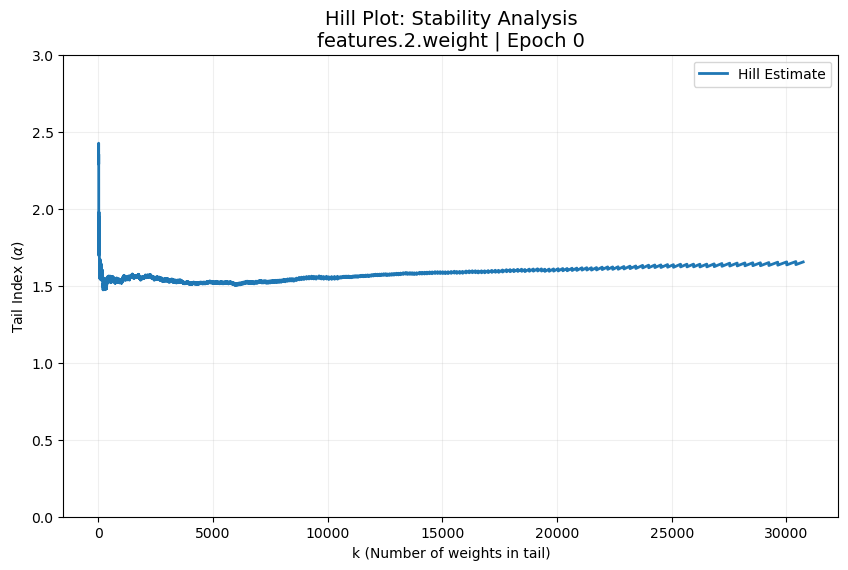

In [6]:
# 1. Pick a representative sample (e.g., the final epoch of a specific run)
TARGET_LAYER = 'features.2.weight'
sample_row = run_df[run_df['layer'] == TARGET_LAYER].iloc[0]
weights = sample_row['weights']
epoch = sample_row['epoch']

# 2. Get the Hill Plot data
ks, alphas = get_hill_plot(weights, max_k_fraction=0.05)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(ks, alphas, color='tab:blue', lw=2, label='Hill Estimate')

# 4. Formatting
plt.title(f"Hill Plot: Stability Analysis\n{TARGET_LAYER} | Epoch {epoch}", fontsize=14)
plt.xlabel("k (Number of weights in tail)")
plt.ylabel(r"Tail Index ($\alpha$)")
plt.grid(True, alpha=0.2)
plt.legend()

# Tighten the Y-axis to see the plateau clearly
if len(alphas) > 0:
    plt.ylim(0.0, 3.0)

plt.show()

In [35]:
def plot_performance_facets(df):
    alphas = sorted(df["init_alpha"].unique())
    sigmas = sorted(df["init_sigma"].unique(), reverse=True)

    # Increase dpi for manuscript quality
    fig, axes = plt.subplots(
        len(sigmas), len(alphas), figsize=(18, 12), sharex=True, sharey=True, dpi=100
    )

    for i, s_val in enumerate(sigmas):
        for j, a_val in enumerate(alphas):
            ax = axes[i, j]
            subset = df[
                (df["init_alpha"] == a_val) & (df["init_sigma"] == s_val)
            ].sort_values("epoch")

            if not subset.empty:
                # Add a faint grid for readability
                ax.grid(True, linestyle=":", alpha=0.6)

                ax.plot(
                    subset["epoch"],
                    subset["train_acc"],
                    color="#1f77b4",
                    lw=2,
                    label="Train",
                )
                ax.plot(
                    subset["epoch"],
                    subset["test_acc"],
                    color="#ff7f0e",
                    lw=2,
                    ls="--",
                    label="Test",
                )

                # Fill the generalization gap
                ax.fill_between(
                    subset["epoch"],
                    subset["train_acc"],
                    subset["test_acc"],
                    color="gray",
                    alpha=0.1,
                )

            # Clean up labels
            if j == 0:
                ax.set_ylabel(f"$\sigma$ = {s_val}", fontweight="bold", fontsize=12)
            if i == len(sigmas) - 1:
                ax.set_xlabel(f"$\\alpha$ = {a_val}", fontweight="bold", fontsize=12)

    # Global labels
    fig.text(0.5, 0.01, "Training Epochs", ha="center", fontsize=14, fontweight="bold")
    fig.text(
        0.01,
        0.5,
        "Accuracy (Top-1)",
        va="center",
        rotation="vertical",
        fontsize=14,
        fontweight="bold",
    )

    # plt.suptitle(
    #     "Impact of Heavy-Tailed Initialization on Learning Trajectories",
    #     fontsize=20,
    #     y=0.98,
    # )

    # 1. Get handles from the first axes
    handles, labels = axes[0, 0].get_legend_handles_labels()

    # 2. Place legend on the left
    # loc="center left" keeps it vertically centered
    # bbox_to_anchor=(0.02, 0.5) places it near the left edge (x=0.02, y=0.5)
    fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.0, 0.94), fontsize=12)

    # 3. Adjust tight_layout to start further right (left=0.15) to make room
    plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95])
    plt.savefig("performance_runs.pdf", bbox_inches="tight")  # Save as PDF for high quality
    plt.show()

def print_performance_summary_table(master_df):
    """
    Groups by run, extracts the final epoch values,
    calculates the generalization gap, and prints a summary.
    """
    # 1. Identify the last epoch for every unique run
    # We group by alpha and sigma (and run_id just in case of multiple seeds)
    summary = master_df.sort_values("epoch").groupby(["init_alpha", "init_sigma", "run_id"]).tail(1).copy()

    # 2. Calculate the Generalization Gap
    # Gap = Train Accuracy - Test Accuracy
    summary["gen_gap"] = summary["train_acc"] - summary["test_acc"]

    # 3. Select and rename columns for a clean display
    display_df = summary[[
        "init_alpha",
        "init_sigma",
        "train_acc",
        "test_acc",
        "gen_gap"
    ]].copy()

    # 4. Sort by sigma (descending) then alpha (ascending) to match your 3x3 plot logic
    display_df = display_df.sort_values(["init_sigma", "init_alpha"], ascending=[False, True])

    # 5. Print with nice formatting
    print("\n" + "="*80)
    print("FINAL PERFORMANCE SUMMARY TABLE")
    print("="*80)
    # Using tabulate or just pandas string formatting
    print(display_df.to_string(index=False, justify='center', float_format=lambda x: f"{x:.4f}"))
    print("="*80)

    return display_df

# Usage:
final_stats_df = print_performance_summary_table(curves_df)


FINAL PERFORMANCE SUMMARY TABLE
 init_alpha  init_sigma  train_acc  test_acc  gen_gap
   1.2000      3.0000     1.0000     0.9297   0.0703 
   1.5000      3.0000     1.0000     0.8855   0.1145 
   2.0000      3.0000     1.0000     0.6164   0.3836 
   1.2000      1.0000     0.9999     0.9683   0.0316 
   1.5000      1.0000     0.9998     0.9692   0.0306 
   2.0000      1.0000     0.9982     0.9751   0.0231 
   1.2000      0.2500     0.9932     0.9602   0.0330 
   1.5000      0.2500     0.9654     0.9365   0.0289 
   2.0000      0.2500     0.1522     0.1468   0.0054 


<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_239694/2723698736.py:48: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma$ = {s_val}", fontweight="bold", fontsize=12)


<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_174079/840816478.py:85: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma$={s_val}", fontweight="bold", fontsize=10)


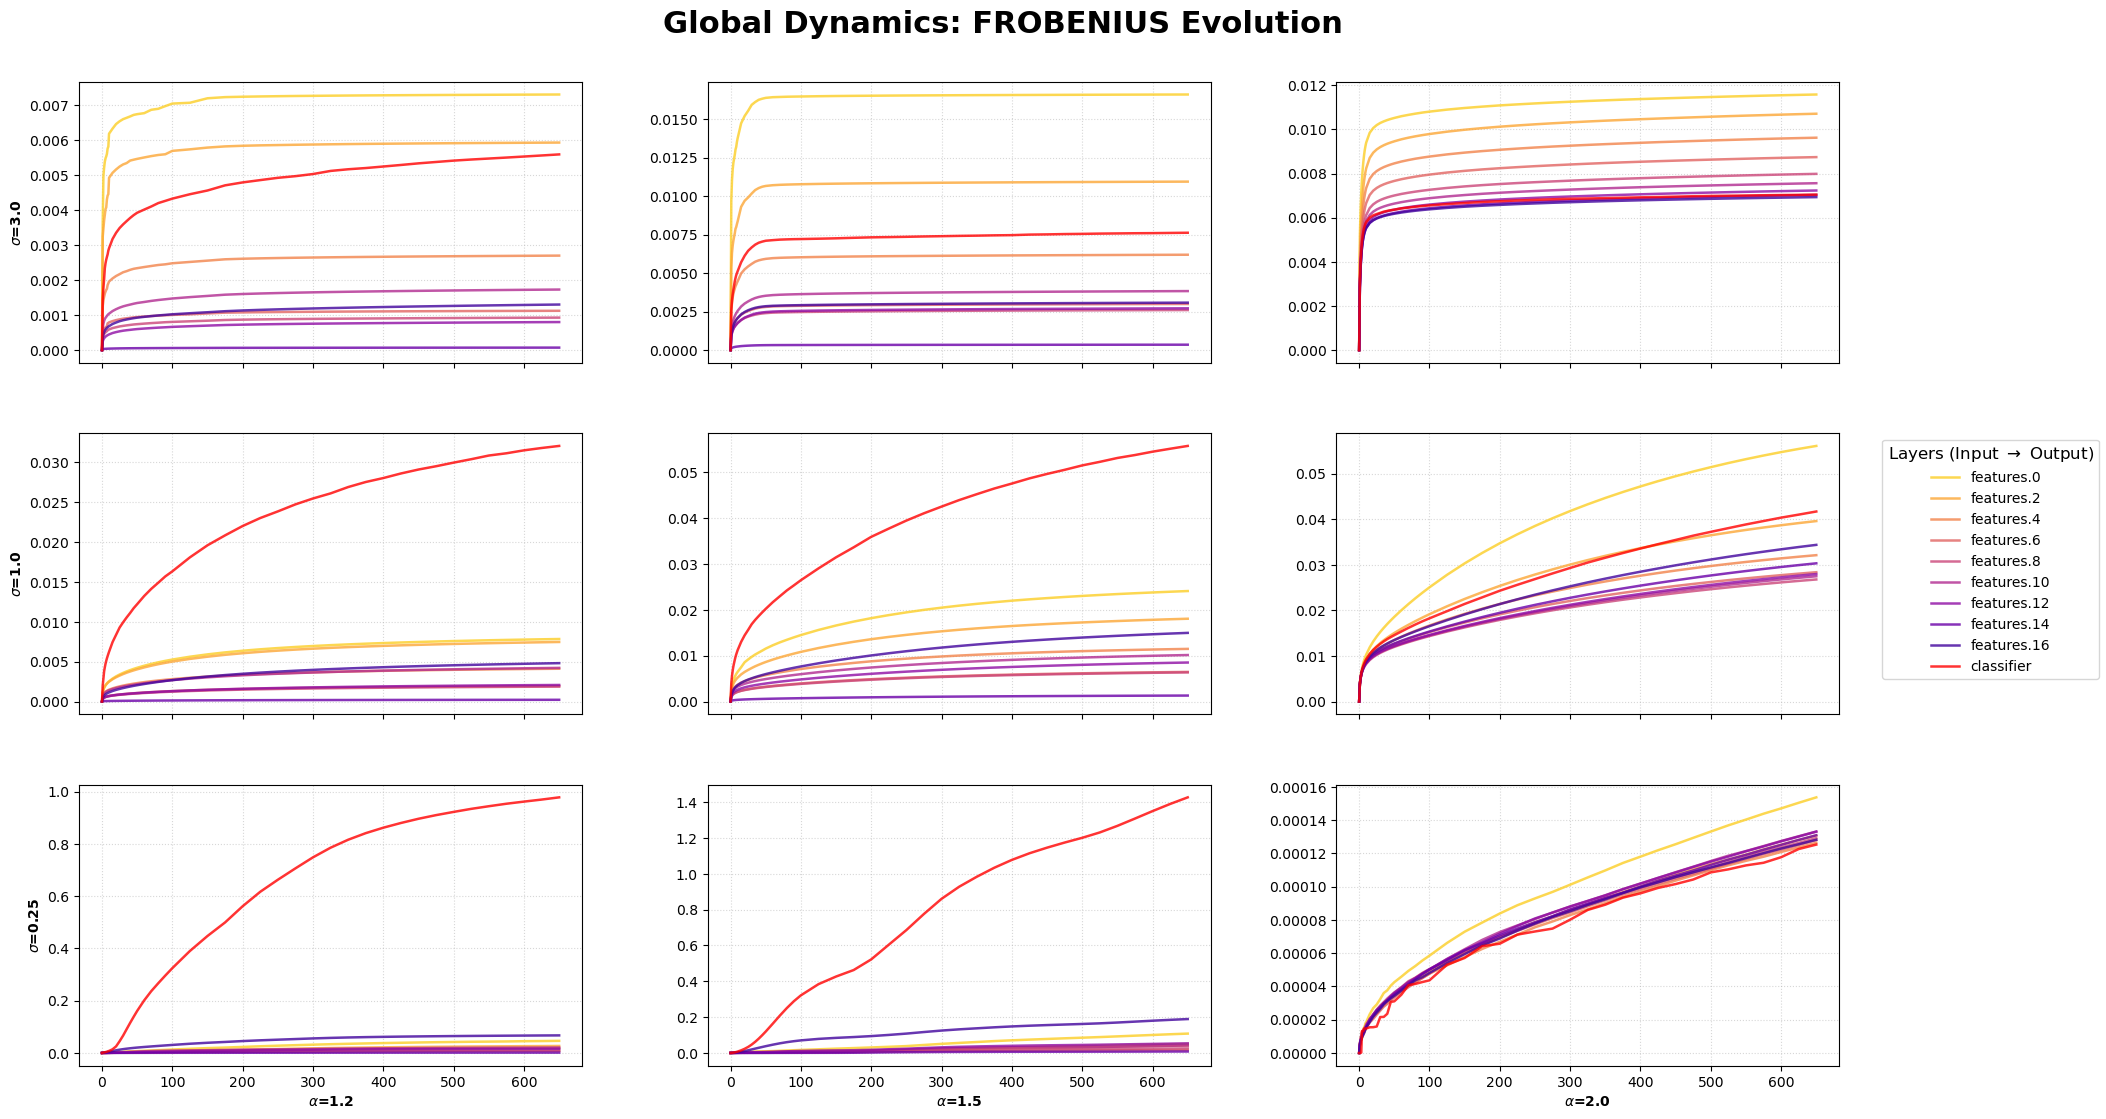

In [29]:
sweep_df = pd.read_csv("sweep_metrics.csv")

def plot_combined_sweep_grid(df, metric_col="frobenius", ignore_classifier=False, plot_ratio=False):
    # 1. Setup Grid Dimensions
    alphas = sorted(df["init_alpha"].unique())
    sigmas = sorted(df["init_sigma"].unique(), reverse=True)

    # 2. Natural Sort & Color Logic
    def extract_number(s):
        nums = re.findall(r"\d+", s)
        return int(nums[0]) if "classifier" not in s else 999

    all_layers = sorted(df["layer"].unique(), key=extract_number)

    # Separate classifier for special coloring
    hidden_layers = [l for l in all_layers if "classifier" not in l]
    classifier_layer = [l for l in all_layers if "classifier" in l]

    # Map colors: Plasma for hidden, distinct color for classifier
    hidden_colors = sns.color_palette("plasma_r", len(hidden_layers))
    layer_to_color = {l: hidden_colors[i] for i, l in enumerate(hidden_layers)}
    for l in classifier_layer:
        layer_to_color[l] = "red"  # Distinctive color for the classifier

    fig, axes = plt.subplots(
        len(sigmas), len(alphas), figsize=(22, 12), sharex=True, sharey=False
    )

    # Track lines for the legend (we only need one set from one subplot)
    legend_elements = []

    for i, s_val in enumerate(sigmas):
        for j, a_val in enumerate(alphas):
            ax = axes[i, j]

            # Filter logic
            mask = (df["init_alpha"] == a_val) & (df["init_sigma"] == s_val)
            if ignore_classifier:
                mask &= ~df["layer"].str.contains("classifier")

            run_subset = df[mask]

            if not run_subset.empty:
                if plot_ratio:
                    if plot_ratio:
                        # --- RATIO LOGIC ---
                        # Pivot to get epochs as index and layers as columns
                        pivot_df = run_subset.pivot(index="epoch", columns="layer", values=metric_col)

                        # Calculate Median of hidden layers across each epoch
                        hidden_median = pivot_df[hidden_layers].median(axis=1)
                        classifier_vals = pivot_df[classifier_layer[0]]

                        # Compute Ratio
                        ratio = classifier_vals / (hidden_median + 1e-12) # epsilon for stability

                        ax.plot(pivot_df.index, ratio, color="red", lw=2.5, label="Cls / Hidden Median")
                        ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.3)
                else:
                    for layer_name in all_layers:
                        layer_data = run_subset[
                            run_subset["layer"] == layer_name
                        ].sort_values("epoch")

                        if not layer_data.empty:
                            y_vals = layer_data[metric_col].values
                            # if metric_col == "frobenius":
                            #     y_vals = y_vals / y_vals[0]

                            (line,) = ax.plot(
                                layer_data["epoch"],
                                y_vals,
                                color=layer_to_color[layer_name],
                                lw=1.8,
                                alpha=0.8,
                            )

                            # Grab handles for the legend only once
                            if i == 0 and j == 0:
                                legend_elements.append(line)

            # Labels and Aesthetics
            ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
            if j == 0:
                ax.set_ylabel(f"$\sigma$={s_val}", fontweight="bold", fontsize=10)
            if i == len(sigmas) - 1:
                ax.set_xlabel(f"$\\alpha$={a_val}", fontweight="bold", fontsize=10)

            # ref_val = 1.0 if metric_col == "frobenius" else a_val
            # ax.axhline(y=ref_val, color="black", linestyle="--", alpha=0.2)
            ax.grid(True, linestyle=":", alpha=0.5)

    # 3. Dedicated Global Legend
    # Use the labels we extracted, making them look pretty
    labels = [
        l.replace(".weight", "")
        for l in all_layers
        if not (ignore_classifier and "classifier" in l)
    ]

    fig.legend(
        legend_elements,
        labels,
        loc="center right",
        title="Layers (Input $\\rightarrow$ Output)",
        title_fontsize="12",
        fontsize="10",
        frameon=True,
    )

    # 4. Final Layout Tweak
    plt.suptitle(
        f"Global Dynamics: {metric_col.upper()} Evolution",
        fontsize=22,
        y=0.96,
        fontweight="bold",
    )

    # 'right=0.88' leaves room for the legend on the right
    fig.subplots_adjust(
        top=0.90, bottom=0.08, left=0.08, right=0.88, hspace=0.25, wspace=0.25
    )

    plt.show()


# Run it
plot_combined_sweep_grid(sweep_df, metric_col="frobenius", ignore_classifier=False, plot_ratio=False)

Found 9 training logs. Aggregating...
Success! Combined 5859 training steps into master log.


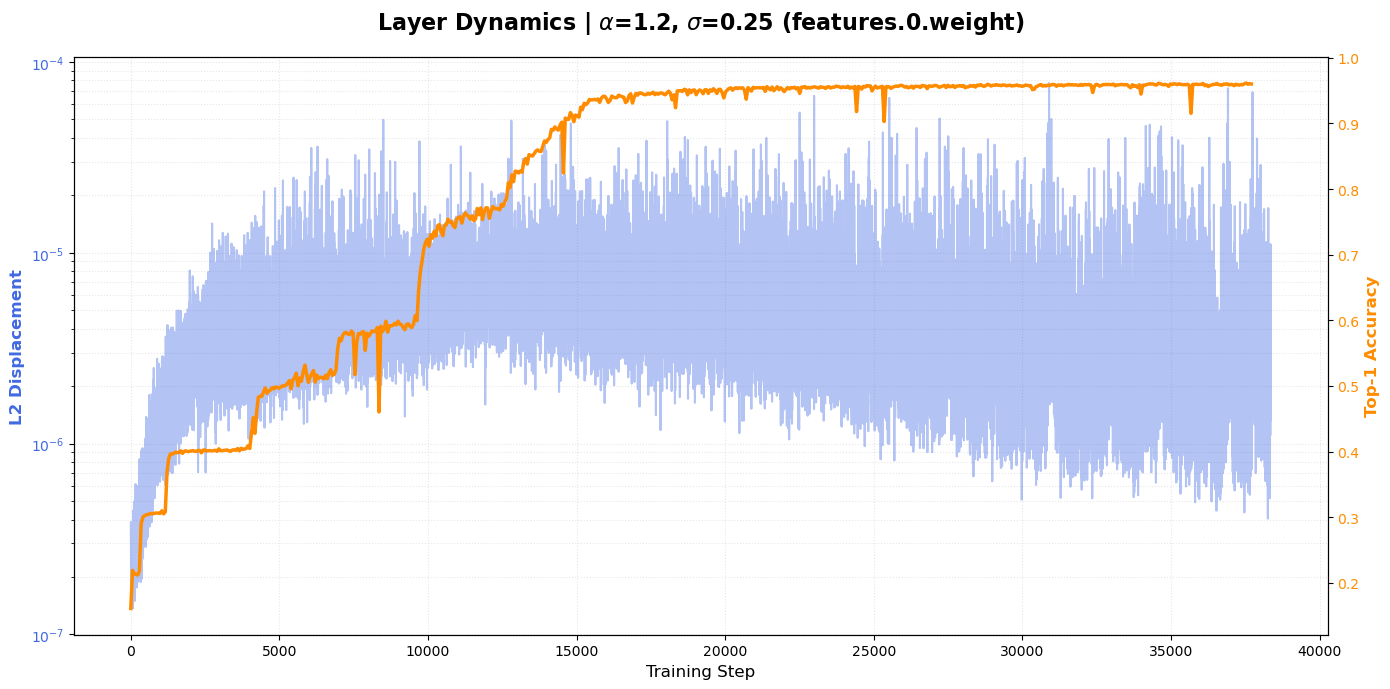

In [23]:
# 1. Setup Parameters
ALPHA_VAL = 1.2
SIGMA_VAL = 0.25
TARGET_LAYER = "features.0.weight" # Select layer to investigate unique dynamics
STEPS_PER_EPOCH = 60000 // 1024

# Load both master DataFrames
msd_df = pd.read_parquet("displacement_database.parquet")
train_df = collect_sweep_learning_curves("mnist_mlp_sweep")
train_df["step"] = train_df["epoch"] * STEPS_PER_EPOCH

# 2. Filter for the "Deep Dive" run
# Isolate the specific heavy-tailed initialization alpha=1.2
msd_run = msd_df.query("alpha == @ALPHA_VAL and sigma == @SIGMA_VAL and layer == @TARGET_LAYER and time_lag == 1")
#msd_run = msd_run.query("step >= 0 and step <= 10000")
train_run = train_df.query("alpha == @ALPHA_VAL and sigma == @SIGMA_VAL")
#train_run = train_run.query("step >= 0 and step <= 10000")

# 3. Create the Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Left Axis: Weight Displacement (The Physical Cause)
color_msd = 'royalblue'
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('L2 Displacement', color=color_msd, fontsize=12, fontweight='bold')
ax1.plot(msd_run["step"], msd_run["l2_dist"], color=color_msd, alpha=0.4, label="Raw Displacement")
ax1.set_yscale('log') # Log scale helps see 'thermal noise' vs 'Lévy flights'
ax1.tick_params(axis='y', labelcolor=color_msd)

# Right Axis: Accuracy (The Computational Effect)
ax2 = ax1.twinx()
color_acc = 'darkorange'
ax2.set_ylabel('Top-1 Accuracy', color=color_acc, fontsize=12, fontweight='bold')
# Map epoch-based accuracy to steps for perfect alignment
ax2.plot(train_run["step"], train_run["test_acc"], color=color_acc, lw=2.5, label="Accuracy")
ax2.tick_params(axis='y', labelcolor=color_acc)

# 4. Final Polish for the Thesis Manuscript
plt.title(f"Layer Dynamics | $\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL} ({TARGET_LAYER})",
          fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, which="both", ls=":", alpha=0.3)
fig.tight_layout()
# plt.savefig("layer_dynamics_deep.pdf", bbox_inches="tight")  # Save as PDF for high quality
plt.show()

Diffusion Exponent (gamma) for features.0.weight: 1.99
Diffusion Exponent (gamma) for classifier.weight: 1.99


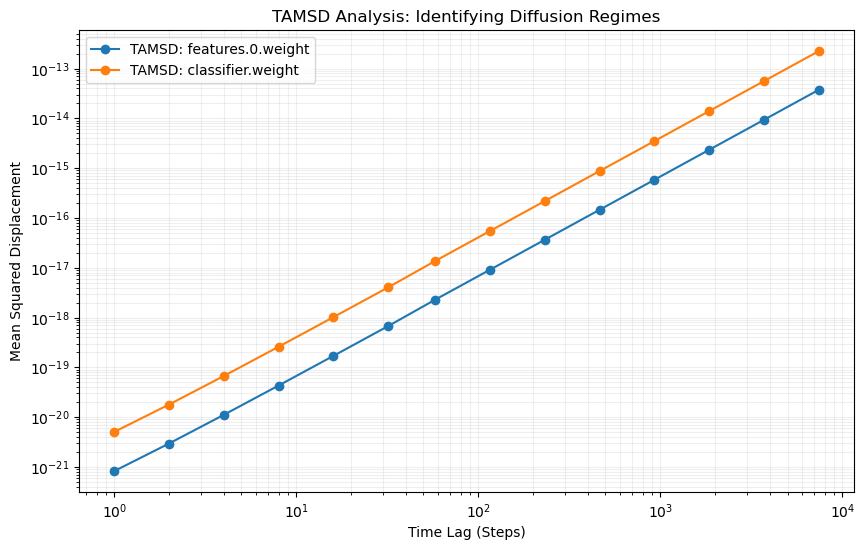

In [12]:
def calculate_tamsd(df, layer_name, alpha_val=2.0, sigma_val=0.25):
    """
    Calculates the Time-Averaged Mean Squared Displacement (TAMSD)
    for a specific layer from the master parquet data.
    """
    # 1. Filter for the specific physics regime and layer
    subset = df.query("alpha == @alpha_val and sigma == @sigma_val and layer == @layer_name")

    # 2. Group by time_lag (tau) to get the time-average
    # TAMSD is the average of squared displacements over the whole trajectory
    # Since your l2_dist is already an average over parameters,
    # we square it and then average over the training steps.
    tamsd_results = subset.groupby("time_lag")["l2_dist"].apply(
        lambda x: np.mean(np.square(x))
    ).reset_index()

    tamsd_results.columns = ["lag", "msd"]
    return tamsd_results

def plot_tamsd_comparison(parquet_path, layers_to_compare):
    df = pd.read_parquet(parquet_path)
    plt.figure(figsize=(10, 6))

    for layer in layers_to_compare:
        res = calculate_tamsd(df, layer)

        # Plotting on Log-Log to find the power-law slope (gamma)
        plt.loglog(res["lag"], res["msd"], marker='o', label=f"TAMSD: {layer}")

        # Calculate local slope (alpha/gamma exponent)
        # Using the last few points to see late-stage diffusion behavior
        log_lag = np.log(res["lag"].values)
        log_msd = np.log(res["msd"].values)
        slope, _ = np.polyfit(log_lag, log_msd, 1)
        print(f"Diffusion Exponent (gamma) for {layer}: {slope:.2f}")

    # Add reference lines for standard physics regimes
    #x_ref = np.geomspace(res["lag"].min(), res["lag"].max(), 10)
    #plt.plot(x_ref, x_ref * (res["msd"].iloc[0]), '--k', alpha=0.5, label="Brownian (Slope=1)")
    #plt.plot(x_ref, (x_ref**2) * (res["msd"].iloc[0]/10), ':k', alpha=0.5, label="Ballistic (Slope=2)")

    plt.title("TAMSD Analysis: Identifying Diffusion Regimes")
    plt.xlabel("Time Lag (Steps)")
    plt.ylabel("Mean Squared Displacement")
    plt.legend()
    plt.grid(True, which="both", alpha=0.2)
    plt.savefig("tamsd_comparison.pdf", bbox_inches="tight")  # Save as PDF for high quality
    plt.show()

# Example usage:
plot_tamsd_comparison("displacement_database.parquet", ["features.0.weight", "classifier.weight"])

<>:64: SyntaxWarning: invalid escape sequence '\g'
<>:65: SyntaxWarning: invalid escape sequence '\g'
<>:64: SyntaxWarning: invalid escape sequence '\g'
<>:65: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_174079/3771493094.py:64: SyntaxWarning: invalid escape sequence '\g'
  plt.axhline(y=1.0, color='firebrick', linestyle='--', alpha=0.5, label='Brownian Limit ($\gamma=1$)')
/tmp/ipykernel_174079/3771493094.py:65: SyntaxWarning: invalid escape sequence '\g'
  plt.axhline(y=2.0, color='forestgreen', linestyle='--', alpha=0.5, label='Ballistic Limit ($\gamma=2$)')


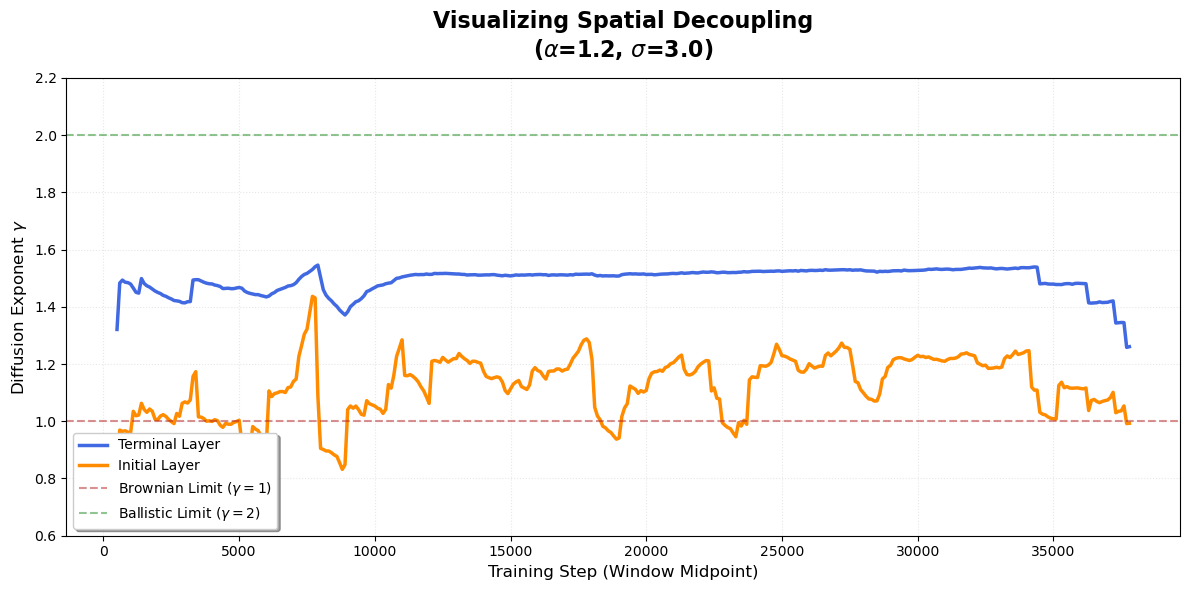

In [25]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

def calculate_rolling_tamsd(msd_df, layer_name, alpha=1.2, sigma=0.25,
                           window_size=2000, stride=200):
    """
    Calculates the evolution of the diffusion exponent gamma over training time.
    """
    subset = msd_df[
        (msd_df['layer'] == layer_name) &
        (msd_df['alpha'] == alpha) &
        (np.isclose(msd_df['sigma'], sigma))
    ].copy()

    subset = subset.sort_values(['step', 'time_lag'])
    all_steps = sorted(subset['step'].unique())
    n_steps = len(all_steps)
    results = []

    for start_idx in range(0, n_steps - window_size, stride):
        end_idx = start_idx + window_size
        window_steps = all_steps[start_idx:end_idx]
        window_data = subset[subset['step'].isin(window_steps)]

        # Calculate MSD: Mean of squared L2 displacements
        tamsd_data = window_data.groupby('time_lag')['l2_dist'].apply(lambda x: np.mean(x**2)).reset_index()
        tamsd_data = tamsd_data[tamsd_data['l2_dist'] > 0]

        if len(tamsd_data) > 3:
            log_tau = np.log10(tamsd_data['time_lag'])
            log_msd = np.log10(tamsd_data['l2_dist'])
            slope, _, r_value, _, _ = linregress(log_tau, log_msd)
            midpoint_step = (window_steps[0] + window_steps[-1]) / 2

            results.append({'step': midpoint_step, 'gamma': slope})

    return pd.DataFrame(results)

# 1. Setup and Data Loading
msd_df = pd.read_parquet("displacement_database.parquet")
ALPHA_VAL = 1.2
SIGMA_VAL = 3.0
layer_engine = "features.16.weight"   # The Terminal Layer
layer_reservoir = "features.0.weight" # The Initial Layer

# 2. Compute Dynamics for both
rolling_engine = calculate_rolling_tamsd(msd_df, layer_engine, alpha=ALPHA_VAL, sigma=SIGMA_VAL)
rolling_reservoir = calculate_rolling_tamsd(msd_df, layer_reservoir, alpha=ALPHA_VAL, sigma=SIGMA_VAL)

# 3. Plotting
plt.figure(figsize=(12, 6))

# The Engine (Blue)
plt.plot(rolling_engine['step'], rolling_engine['gamma'],
         color='royalblue', lw=2.5, label='Terminal Layer')

# The Reservoir (Orange)
plt.plot(rolling_reservoir['step'], rolling_reservoir['gamma'],
         color='darkorange', lw=2.5, label='Initial Layer')

# Physics Reference Lines
plt.axhline(y=1.0, color='firebrick', linestyle='--', alpha=0.5, label='Brownian Limit ($\gamma=1$)')
plt.axhline(y=2.0, color='forestgreen', linestyle='--', alpha=0.5, label='Ballistic Limit ($\gamma=2$)')

# Final Polish
plt.title(f"Visualizing Spatial Decoupling\n($\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL})",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Training Step (Window Midpoint)", fontsize=12)
plt.ylabel(r"Diffusion Exponent $\gamma$", fontsize=12)
plt.ylim(0.6, 2.2)
plt.grid(True, which="both", ls=":", alpha=0.3)
plt.legend(loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("diffusion_curve.pdf", bbox_inches="tight")  # Save as PDF for high quality
plt.show()

Calculating Distance Correlation for 10 layers...


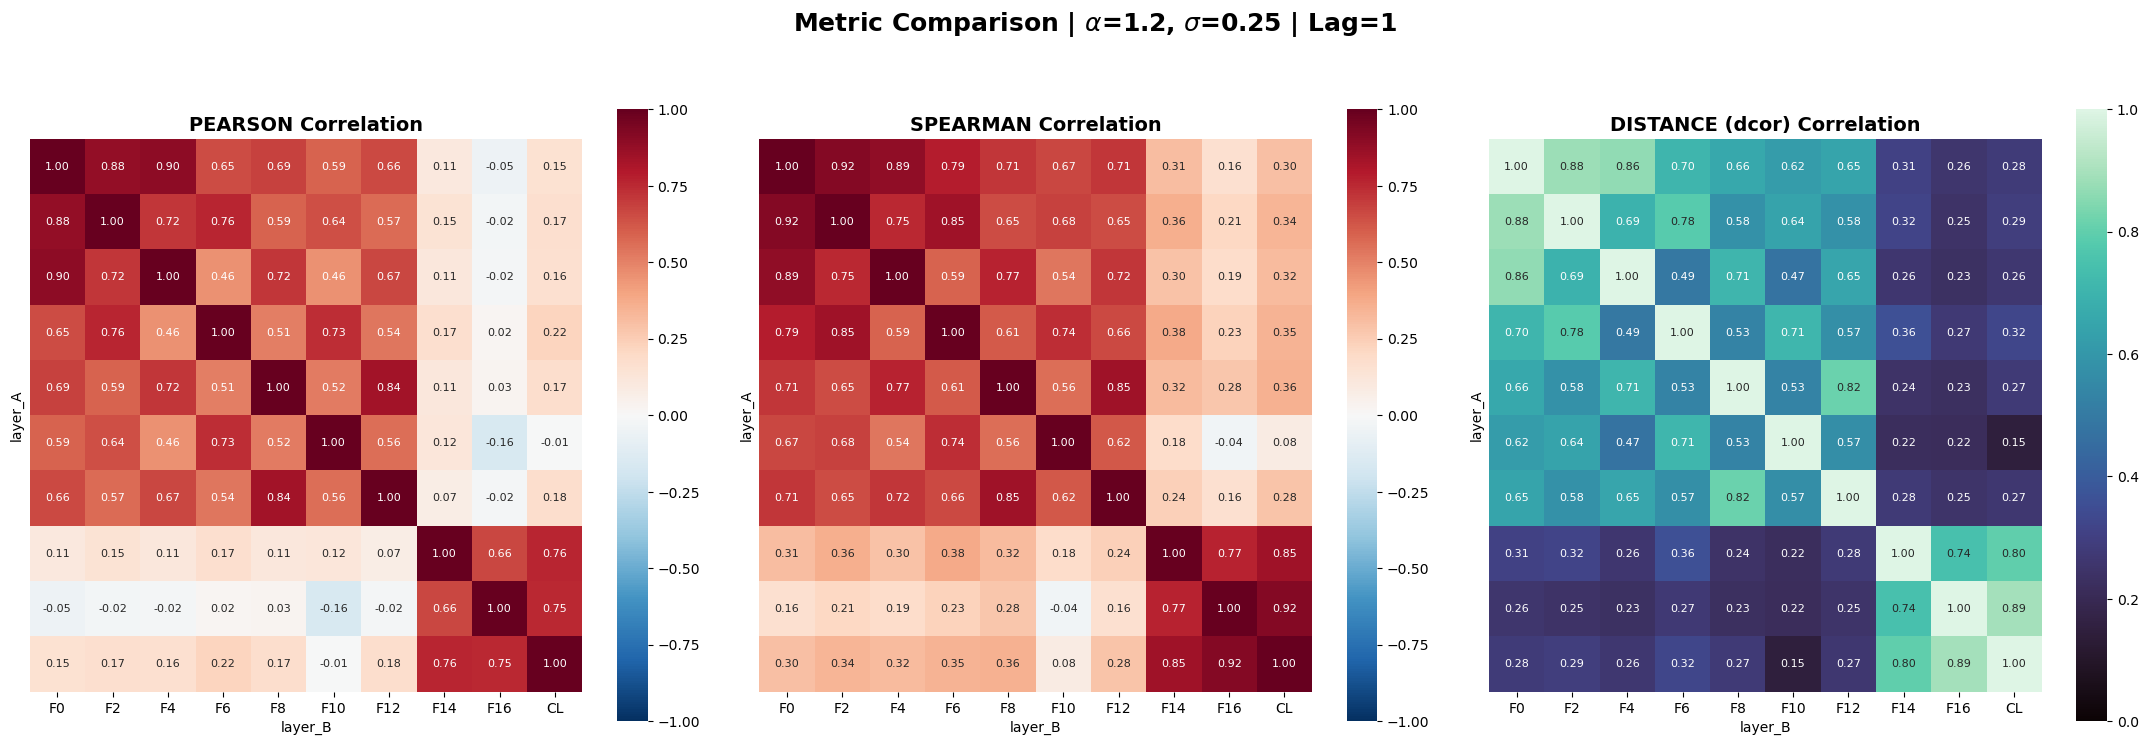

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import dcor  # Distance Correlation

def compute_and_plot_trinity(parquet_path, alpha_val, sigma_val, time_lag=1, metric_col="l2_dist"):
    """
    Computes Pearson, Spearman, and Distance Correlation from the master Parquet
    and visualizes them using the Trinity Heatmap layout.
    """
    # 1. Load and filter the master scalar database
    df_full = pd.read_parquet(parquet_path)

    # Filter for physics regime and the specific lag (tau)
    subset = df_full[
        (df_full['alpha'] == alpha_val) &
        (np.isclose(df_full['sigma'], sigma_val)) &
        (df_full['time_lag'] == time_lag)
    ].copy()

    if subset.empty:
        print(f"Error: No data found for alpha={alpha_val}, sigma={sigma_val}, lag={time_lag}")
        return

    # 2. Pivot data to create a Time-Series Matrix (Rows=Steps, Columns=Layers)
    # We use 'step' as the index to ensure we correlate displacements at the same time point
    ts_matrix = subset.pivot(index="step", columns="layer", values=metric_col).dropna()
    layers = ts_matrix.columns.tolist()

    # 3. Calculate Correlation Matrices
    pearson_mat = ts_matrix.corr(method='pearson')
    spearman_mat = ts_matrix.corr(method='spearman')

    # Distance Correlation (Manual pair-wise calculation as it's not native to Pandas)
    n_layers = len(layers)
    dcor_mat = pd.DataFrame(np.ones((n_layers, n_layers)), index=layers, columns=layers)

    print(f"Calculating Distance Correlation for {n_layers} layers...")
    for i in range(n_layers):
        for j in range(i + 1, n_layers):
            val = dcor.distance_correlation(ts_matrix.iloc[:, i], ts_matrix.iloc[:, j])
            dcor_mat.iloc[i, j] = dcor_mat.iloc[j, i] = val

    # 4. Helper to format for your original plotting function
    def melt_matrix(mat):
        # Ensure the index has a predictable name before resetting
        mat.index.name = "layer_A"
        melted = mat.reset_index().melt(id_vars="layer_A", var_name="layer_B", value_name="correlation")
        melted['alpha'] = alpha_val
        melted['sigma'] = sigma_val
        melted['delta_t'] = time_lag
        return melted

    df_p = melt_matrix(pearson_mat)
    df_s = melt_matrix(spearman_mat)
    df_d = melt_matrix(dcor_mat)

    # 5. Call your existing plotting logic
    plot_correlation_trinity(df_p, df_s, df_d, alpha_val, sigma_val, delta_t=time_lag)

def plot_correlation_trinity(pearson_df, spearman_df, dcor_df, alpha_val, sigma_val, delta_t=1):
    """
    Your original plotting function with minor tweaks to handle the DataFrame format.
    """
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

    methods = [
        ("PEARSON", pearson_df, "RdBu_r", (-1, 1)),
        ("SPEARMAN", spearman_df, "RdBu_r", (-1, 1)),
        ("DISTANCE (dcor)", dcor_df, "mako", (0, 1))
    ]

    def sort_key(name):
        # Sorts features.0, features.16, classifier...
        nums = re.findall(r'\d+', name)
        if 'classifier' in name.lower(): return 999
        return int(nums[0]) if nums else 0

    for i, (name, df, cmap, (vmin, vmax)) in enumerate(methods):
        ax = axes[i]

        # Standardize matrix for heatmap
        matrix = df.pivot(index="layer_A", columns="layer_B", values="correlation")
        ordered = sorted(matrix.index.tolist(), key=sort_key)
        matrix = matrix.reindex(index=ordered, columns=ordered)

        short_labels = [l.replace('.weight', '').replace('features.', 'F').replace('classifier', 'CL') for l in ordered]

        sns.heatmap(
            matrix, ax=ax, annot=True, fmt=".2f", annot_kws={"size": 8},
            cmap=cmap, vmin=vmin, vmax=vmax, square=True, cbar=True,
            xticklabels=short_labels,
            yticklabels=short_labels if i == 0 else False
        )

        ax.set_title(f"{name} Correlation", fontsize=14, fontweight='bold')

    plt.suptitle(f"Metric Comparison | $\\alpha$={alpha_val}, $\\sigma$={sigma_val} | Lag={delta_t}",
                 fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig("correlations.pdf", bbox_inches="tight")  # Save as PDF for high quality
    plt.show()

# EXECUTION:
compute_and_plot_trinity("displacement_database.parquet", alpha_val=1.2, sigma_val=0.25, time_lag=1)

In [ ]:
# 1. Initialization and Data Extraction

LAYER_KEY = 'features.2.weight'
W_final = get_layer_from_checkpoint(RUN_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(RUN_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)

nu_final = get_singular_values(W_final)
nu_init  = get_singular_values(W_init)

# Use the official adaptive Broadener from source code

broadener = GaussBroadening(winSize=15, method='replicate')

fig, ax = plt.subplots(figsize=(9, 6))

# Determine global x-limit based on the maximum singular value found in training

x_limit = np.max(nu_final) * 1.2

data_configs = [
(nu_init, 'Initialization (Epoch 0)', 'red'),
(nu_final, 'Fully Trained', '#1d3557') # Dark blue matching paper Fig 1
]

for nu, label, color in data_configs:
    # A. EMPIRICAL DENSITY (Solid Line)
    # Generate high-resolution x and pdf using the official iterative sampler
    x_emp, pdf_emp = pdf_from_spectrum(nu, nSamples=20, broadener=broadener)

    # Mask to ensure it only plots within the viewport
    mask = (x_emp >= 0) & (x_emp <= x_limit)
    ax.plot(x_emp[mask], pdf_emp[mask], color=color, lw=2, label=label, zorder=4)

    # B. RMT THEORY FIT (Dashed Line)
    # [cite_start]This uses the authors' logic to fit ONLY the random bulk [cite: 2427, 2429]
    # range_of_y_to_fit=0.7 prevents the tail from stretching the bulk fit
    a_fit, nuMin_fit, nuMax_fit, _ = fit_marcenkoPastur(nu, broadener, range_of_y_to_fit=0.7)

    # [cite_start]Evaluate theory curve within its specific theoretical support [cite: 2381, 2386]
    x_bulk = np.linspace(nuMin_fit, nuMax_fit, 400)
    y_bulk = marcenkoPastur(x_bulk, a_fit, nuMax_fit, nuMin_fit)

    ax.plot(x_bulk, y_bulk, color='black', linestyle='--', lw=1.2, zorder=5)

    # 2. Physical Review E Aesthetics (Matching Figure 1)

    ax.set_yscale('linear')
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, x_limit)

    ax.set_xlabel(r'singular value $\nu$', fontsize=13)
    ax.set_ylabel('probability density', fontsize=13)

# Professional scientific formatting

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_dual_level_variance(w_init, w_final, win_size=15):
    """
    Recreates Fig 3: Level number variance comparing initial (red)
    and trained (blue) weights.
    """
    # 1. Extract and sort singular values (Cite: 709, 860)
    s_init = np.sort(get_singular_values(w_init))
    s_final = np.sort(get_singular_values(w_final))

    # 2. Setup Broadener and Parameters (Cite: 754, 758)
    broadener = GaussBroadening(winSize=win_size, method='replicate')
    L_range = np.linspace(0.1, 20, 200) # (Cite: 777)
    opts = {'tol': 0.01, 'maxIterations': 1000, 'minIterations': 100}

    # 3. Compute empirical variance for both (Cite: 774, 775)
    _, sigma_init = level_number_variance(s_init, broadener, L_range, **opts)
    _, sigma_final = level_number_variance(s_final, broadener, L_range, **opts)

    # 4. Theoretical GOE Prediction (Cite: 777, 959)
    gamma = np.euler_gamma
    sigma_goe = (2 / np.pi**2) * (np.log(2 * np.pi * L_range) + gamma + 1 - (np.pi**2 / 8))

    # 5. Visualization (Matches Fig 3/7 colors) (Cite: 810, 995)
    plt.figure(figsize=(8, 6))

    # GOE Theory - Black Dashed (Cite: 811)
    plt.plot(L_range, sigma_goe, 'k--', lw=2, label='Theory (GOE)')

    # Initial - Red (Cite: 779, 810)
    plt.plot(L_range, sigma_init, color='red', lw=1.5, alpha=0.8, label='Initial')

    # Trained - Blue (Cite: 779, 810)
    plt.plot(L_range, sigma_final, color='#1f77b4', lw=1.5, alpha=0.8, label='Trained')

    plt.xlabel('l', fontsize=14)
    plt.ylabel(r'$\Sigma^2(l)$', fontsize=14)
    plt.title(f'Level Number Variance', fontsize=14)
    plt.xlim(0, 20)
    plt.ylim(0, 2.0)
    plt.legend(frameon=False)
    plt.grid(alpha=0.2)
    plt.show()

# Example Usage:
LAYER_KEY = 'features.2.weight'
W_final = get_layer_from_checkpoint(RUN_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(RUN_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)
plot_dual_level_variance(W_init, W_final, win_size=15)

In [ ]:
def get_full_weight_chain(checkpoint_path, layer_names=None):
    """
    Loads a checkpoint and returns weights in the SPECIFIC order of the forward pass.
    """
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    state_dict = ckpt.get('model_state', ckpt)

    # If you know your layer names, list them here in order!
    # Example for a common CIFAR MLP:
    if layer_names is None:
        # Fallback: try to filter and sort, but print the order so you can verify
        keys = sorted([k for k in state_dict.keys() if 'weight' in k and 'bn' not in k.lower()],
                      key=lambda x: [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', x)])
    else:
        keys = layer_names

    # print(f"  -> Building chain from keys: {keys}")
    return [state_dict[k].float() for k in keys]

def plot_lyapunov_evolution(run_dir, activation='relu', input_dim=784,
                                     layer_names=None, num_samples=20):
    """
    Analyzes checkpoints and plots the Mean MLE with a Standard Deviation shaded region.

    Args:
        num_samples: Number of times to run the MLE per checkpoint (the 'X' times).
    """
    checkpoint_dir = Path(run_dir) / "checkpoints"
    if not checkpoint_dir.exists():
        checkpoint_dir = Path(run_dir)

    checkpoint_files = list(checkpoint_dir.glob("weights_epoch_*.pth"))
    if not checkpoint_files:
        checkpoint_files = list(checkpoint_dir.glob("*.pth"))

    def extract_epoch(f):
        nums = re.findall(r'\d+', f.name)
        return int(nums[-1]) if nums else 0

    checkpoint_files.sort(key=extract_epoch)

    epochs = []
    mle_means = []
    mle_stds = []

    # print(f"Processing {len(checkpoint_files)} checkpoints (Ensemble size: {num_samples})...")

    for f in checkpoint_files:
        # Load weights once for the checkpoint
        weights = get_full_weight_chain(f, layer_names=layer_names)
        if not weights: continue

        # Run the calculation X times to account for stochasticity
        batch_mles = []
        for _ in range(num_samples):
            # Generate a new random input sample for each iteration
            sample_input = torch.randn(1, input_dim)
            mle = calculate_true_mle(weights, sample_input, activation=activation)
            batch_mles.append(mle)

        epochs.append(extract_epoch(f))
        mle_means.append(np.mean(batch_mles))
        mle_stds.append(np.std(batch_mles))

        # print(f"  Epoch {epochs[-1]:3d} | Mean MLE: {mle_means[-1]:.4f} +/- {mle_stds[-1]:.4f}")

    # Convert to numpy arrays for plotting
    epochs = np.array(epochs)
    means = np.array(mle_means)
    stds = np.array(mle_stds)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))

    # Plot the shaded Standard Deviation region
    plt.fill_between(epochs, means - stds, means + stds,
                     color='#e31a1c', alpha=0.2, label=f'StDev (N={num_samples})')

    # Plot the Mean line
    plt.plot(epochs, means, 'o-', color='#e31a1c', markersize=4, linewidth=2, label='Ensemble Mean MLE')

    # Criticality Reference
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Criticality ($\lambda=0$)')

    plt.title(f"Dynamical Stability Ensemble: {Path(run_dir).name}", fontsize=12)
    plt.xlabel("Training Epoch", fontsize=11)
    plt.ylabel("Maximal Lyapunov Exponent ($\lambda$)", fontsize=11)
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---
CIFAR_LAYERS = [
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    # 'features.6.weight',
    # 'features.8.weight',
    # 'features.10.weight',
    # 'features.12.weight',
    # 'features.14.weight',
    # 'features.16.weight',
    'classifier.weight'
]
plot_lyapunov_evolution(RUN_PATH, activation='relu', input_dim=3072, layer_names=CIFAR_LAYERS, num_samples=100)

In [ ]:
from torchvision.datasets import CIFAR10, MNIST
from torch.utils.data import DataLoader
import torch.nn as nn

def calculate_empirical_ql_flow(run_dir, alpha=1.2, device='cpu'):
    """
    Calculates the empirical scale parameter q_l across all layers and checkpoints
    strictly following the alpha-moment definition in the Qu et al. manuscript.
    """
    run_path = Path(run_dir)
    with open(run_path / "run_config.json", "r") as f:
        config = json.load(f)

    # 1. Data Setup (To get the input x0)
    data_cfg = config['data_config']
    norm_mean = data_cfg['transforms'][1]['Normalize']['mean']
    norm_std = data_cfg['transforms'][1]['Normalize']['std']

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std)
    ])

    ds_class = CIFAR10 if data_cfg['dataset_name'] == 'CIFAR10' else MNIST
    dataset = ds_class(root='./data', train=False, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=data_cfg['batch_size'], shuffle=True)

    # Get initial input x0
    x, _ = next(iter(loader))
    x = x.to(device).view(x.size(0), -1)

    # 2. Model Reconstruction
    model_params = config['model_params']['kwargs']
    # Extract Dw/Db if parameterized in your init, else we treat the weights as-is
    model = GeneralMLP(**model_params).to(device)
    activation_fn = nn.ReLU() if model_params['activation_name'] == 'relu' else nn.Tanh()

    checkpoint_dir = run_path / "checkpoints"
    ckpt_files = sorted(list(checkpoint_dir.glob("weights_epoch_*.pth")),
                        key=lambda x: int(x.stem.split('_')[-1]))

    results = {} # Epoch -> List of q_l values

    for ckpt_p in ckpt_files:
        epoch = int(ckpt_p.stem.split('_')[-1])
        state = torch.load(ckpt_p, map_location=device)
        model.load_state_dict(state.get('model_state', state))
        model.eval()

        # q0: The starting energy of the input data
        # Equation: q0 = (1/N) * sum(|x0|^alpha)
        q_flow = [torch.mean(torch.abs(x)**alpha).item()]

        curr_act = x
        with torch.no_grad():
            # Propagate through the 'features' Sequential block
            for layer in model.features:
                if isinstance(layer, nn.Linear):
                    # Linear transformation: h = Wx + b
                    h = layer(curr_act)
                    # Non-linear activation: x_next = phi(h)
                    curr_act = activation_fn(h)

                    # Calculate empirical q_l for this layer
                    # Strictly: q_l = mean(|phi(h)|^alpha)
                    q_l = torch.mean(torch.abs(curr_act)**alpha).item()
                    q_flow.append(q_l)

            # Final Classifier Layer
            h_final = model.classifier(curr_act)
            # The paper usually stops at the last hidden layer, but we include it for completeness
            q_final = torch.mean(torch.abs(h_final)**alpha).item()
            q_flow.append(q_final)

        results[epoch] = q_flow
        print(f"Epoch {epoch} | q_start: {q_flow[0]:.4f} | q_end: {q_flow[-1]:.4f}")

    return results

# --- 4. PLOTTING THE "ENERGY FLOW" ---

def plot_energy_flow(results, layer_names):
    plt.figure(figsize=(10, 6))

    # Plot first, middle, and last epoch to see the evolution
    epochs_to_show = [min(results.keys()), max(results.keys()) // 2, max(results.keys())]

    for epoch in epochs_to_show:
        if epoch in results:
            plt.plot(range(len(layer_names)), results[epoch], 'o-', label=f'Epoch {epoch}')

    plt.xticks(range(len(layer_names)), layer_names, rotation=45)
    plt.yscale('log') # Scale parameters often vary by orders of magnitude
    plt.ylabel("Scale Parameter $q_l$ (Log Scale)")
    plt.xlabel("Layer")
    plt.title("Lévy Mean Field: Energy Flow Across Layers")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

LAYERS = [
    'INPUT',
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    # 'features.6.weight',
    # 'features.8.weight',
    # 'features.10.weight',
    # 'features.12.weight',
    # 'features.14.weight',
    # 'features.16.weight',
    'classifier.weight'
]
results = calculate_empirical_ql_flow(RUN_PATH, alpha=1.2, device='cuda')
plot_energy_flow(results, LAYERS)